In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install facenet-pytorch --quiet

print("Drive mounted and dependencies installed.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted and dependencies installed.


In [ ]:
import gc
import copy
import time
import json
import cv2
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.models as models
from torchvision.models.optical_flow import raft_small, Raft_Small_Weights
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast
from pathlib import Path
from tqdm import tqdm

from facenet_pytorch import MTCNN

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)

print("All libraries imported successfully.")
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

All libraries imported successfully.
PyTorch version : 2.2.2+cu121
CUDA available  : True


In [ ]:
PROJECT_ROOT = Path("/content/drive/MyDrive/deepfake_binary_project")

PROC_ROOT  = PROJECT_ROOT / "processed"
INDEX_DIR  = PROJECT_ROOT / "index"
MODEL_DIR  = PROJECT_ROOT / "models"
PLOTS_DIR  = PROJECT_ROOT / "eda_plots"

FFPP_FACES_ROOT    = PROC_ROOT / "ffpp_face_crops_224"
CELEBDF_FACES_ROOT = PROC_ROOT / "celebdf_face_crops_224"
RAFT_FACES_ROOT    = PROC_ROOT / "face_crops_224_interpolated"

# Local disk path — faster than Drive during training
RAFT_LOCAL = Path("/content/raft_frames")

MODEL_DIR.mkdir(parents=True, exist_ok=True)

SEED            = 42
NUM_FRAMES      = 8
NUM_FRAMES_RAFT = NUM_FRAMES * 2   # 16 after interpolation

# ── His settings ──
IMG_SIZE      = 112
KINETICS_MEAN = [0.43216, 0.394666, 0.37645]
KINETICS_STD  = [0.22803, 0.22145, 0.216989]

BATCH_SIZE  = 8
NUM_WORKERS = 4
ACCUM_STEPS = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)

print(f"Device              : {device} ({torch.cuda.get_device_name(0)})")
print(f"Base frames/video   : {NUM_FRAMES}")
print(f"RAFT frames/video   : {NUM_FRAMES_RAFT}")
print(f"Image size          : {IMG_SIZE}x{IMG_SIZE}  (Kinetics-400 setting)")
print(f"Batch size          : {BATCH_SIZE}")
print(f"Gradient accum steps: {ACCUM_STEPS}")
print(f"Effective batch size: {BATCH_SIZE * ACCUM_STEPS}")

Device              : cuda (Tesla T4)
Base frames/video   : 8
RAFT frames/video   : 16
Image size          : 112x112  (Kinetics-400 setting)
Batch size          : 8
Gradient accum steps: 4
Effective batch size: 32


In [ ]:
train_df   = pd.read_csv(INDEX_DIR / "ffpp_train.csv")
val_df     = pd.read_csv(INDEX_DIR / "ffpp_val.csv")
test_df    = pd.read_csv(INDEX_DIR / "ffpp_test.csv")
df_celebdf = pd.read_csv(INDEX_DIR / "celebdf_test.csv")

print("Index files loaded successfully.")
print(f"\nFF++ Train : {len(train_df)} videos  (real: {(train_df.binary_target==0).sum()} | fake: {(train_df.binary_target==1).sum()})")
print(f"FF++ Val   : {len(val_df)} videos  (real: {(val_df.binary_target==0).sum()} | fake: {(val_df.binary_target==1).sum()})")
print(f"FF++ Test  : {len(test_df)} videos  (real: {(test_df.binary_target==0).sum()} | fake: {(test_df.binary_target==1).sum()})")
print(f"\nCeleb-DF v2: {len(df_celebdf)} videos  (real: {(df_celebdf.binary_target==0).sum()} | fake: {(df_celebdf.binary_target==1).sum()})")

Index files loaded successfully.

FF++ Train : 4200 videos  (real: 700 | fake: 3500)
FF++ Val   : 900 videos  (real: 150 | fake: 750)
FF++ Test  : 900 videos  (real: 150 | fake: 750)

Celeb-DF v2: 6529 videos  (real: 890 | fake: 5639)


In [ ]:
# Kinetics-400 normalization to match his training settings
# Resize to 112x112 on-the-fly — our saved JPEGs are 224x224
train_transform = T.Compose([
    T.ToPILImage(),
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(mean=KINETICS_MEAN, std=KINETICS_STD),
])

val_transform = T.Compose([
    T.ToPILImage(),
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=KINETICS_MEAN, std=KINETICS_STD),
])

class DeepfakeDataset(Dataset):
    """
    Loads pre-extracted RAFT interpolated face crops (saved at 224x224),
    resizes to 112x112 on-the-fly to match teammate's training settings.
    Returns a tensor of shape (T, C, H, W) and a binary label.
    """
    def __init__(self, df, faces_root, transform=None, num_frames=NUM_FRAMES_RAFT):
        self.df         = df.reset_index(drop=True)
        self.faces_root = Path(faces_root)
        self.transform  = transform
        self.num_frames = num_frames

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row       = self.df.iloc[idx]
        vid_stem  = Path(row["path"]).stem
        label     = int(row["binary_target"])
        frame_dir = self.faces_root / row["binary_label"] / vid_stem

        frames = []
        for i in range(self.num_frames):
            img = cv2.imread(str(frame_dir / f"frame_{i:02d}.jpg"))
            if img is None:
                img = np.zeros((224, 224, 3), dtype=np.uint8)
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            if self.transform:
                img = self.transform(img)
            else:
                img = T.Compose([T.ToPILImage(), T.Resize((IMG_SIZE, IMG_SIZE)),
                                  T.ToTensor()])(img)
            frames.append(img)

        return torch.stack(frames), torch.tensor(label, dtype=torch.long)

print("Transforms and DeepfakeDataset defined.")
print(f"  Input JPEG size  : 224x224 (saved on Drive)")
print(f"  Model input size : {IMG_SIZE}x{IMG_SIZE} (resized on-the-fly)")
print(f"  Normalization    : Kinetics-400")

Transforms and DeepfakeDataset defined.
  Input JPEG size  : 224x224 (saved on Drive)
  Model input size : 112x112 (resized on-the-fly)
  Normalization    : Kinetics-400


In [ ]:
targets = train_df["binary_target"].values
counts  = np.bincount(targets)
weights = 1.0 / counts[targets]
sampler = WeightedRandomSampler(
    weights     = torch.tensor(weights, dtype=torch.float),
    num_samples = len(weights),
    replacement = True
)

# Reading directly from Drive — evaluation only, no training
train_dataset   = DeepfakeDataset(train_df,   RAFT_FACES_ROOT, transform=train_transform)
val_dataset     = DeepfakeDataset(val_df,     RAFT_FACES_ROOT, transform=val_transform)
test_dataset    = DeepfakeDataset(test_df,    RAFT_FACES_ROOT, transform=val_transform)
celebdf_dataset = DeepfakeDataset(df_celebdf, RAFT_FACES_ROOT, transform=val_transform)

train_loader   = DataLoader(train_dataset,   batch_size=BATCH_SIZE, sampler=sampler,
                            num_workers=NUM_WORKERS, pin_memory=True)
val_loader     = DataLoader(val_dataset,     batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
test_loader    = DataLoader(test_dataset,    batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
celebdf_loader = DataLoader(celebdf_dataset, batch_size=32, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train dataset    : {len(train_dataset)} videos  | {len(train_loader)} batches")
print(f"Val dataset      : {len(val_dataset)} videos  | {len(val_loader)} batches")
print(f"Test dataset     : {len(test_dataset)} videos  | {len(test_loader)} batches")
print(f"Celeb-DF dataset : {len(celebdf_dataset)} videos | {len(celebdf_loader)} batches")
print(f"\nReading from : {RAFT_FACES_ROOT}")
print(f"Real weight  : {weights[targets==0][0]:.4f} | Fake weight : {weights[targets==1][0]:.4f}")

Train dataset    : 4200 videos  | 525 batches
Val dataset      : 900 videos  | 113 batches
Test dataset     : 900 videos  | 113 batches
Celeb-DF dataset : 6529 videos | 205 batches

Reading from : /content/drive/MyDrive/deepfake_binary_project/processed/face_crops_224_interpolated
Real weight  : 0.0014 | Fake weight : 0.0003


In [ ]:
class R3D18RAFTDetector(nn.Module):
    """
    R3D-18 binary deepfake detector operating on RAFT-interpolated frames.
    Architecture matches teammate's R3D18RAFTDeepfakeDetector.
    Input: (B, T=16, C, H, W) where H=W=112 (Kinetics-400 setting)
    """
    def __init__(self, dropout=0.3):
        super().__init__()
        backbone = models.video.r3d_18(weights=models.video.R3D_18_Weights.DEFAULT)
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])
        self.dropout           = nn.Dropout(dropout)
        self.classifier        = nn.Linear(512, 2)

    def forward(self, x):
        # x: (B, T, C, H, W) → (B, C, T, H, W) for 3D conv
        x        = x.permute(0, 2, 1, 3, 4)
        features = self.feature_extractor(x)  # (B, 512, 1, 1, 1)
        features = features.flatten(1)        # (B, 512)
        features = self.dropout(features)
        return self.classifier(features)      # (B, 2)

torch.cuda.empty_cache()
gc.collect()

raft_r3d = R3D18RAFTDetector(dropout=0.3).to(device)

with torch.no_grad():
    dummy = torch.randn(2, NUM_FRAMES_RAFT, 3, IMG_SIZE, IMG_SIZE).to(device)
    out   = raft_r3d(dummy)

print(f"R3D-18 + RAFT initialized.")
print(f"Input shape  : {dummy.shape}  (B, T=16, C={IMG_SIZE}, H={IMG_SIZE})")
print(f"Output shape : {out.shape}")
print(f"GPU memory   : {torch.cuda.memory_allocated()/1e9:.2f} GB")

R3D-18 + RAFT initialized.
Input shape  : torch.Size([2, 16, 3, 112, 112])  (B, T=16, C=112, H=112)
Output shape : torch.Size([2, 2])
GPU memory   : 0.15 GB


In [ ]:
his_ckpt_path = MODEL_DIR / "r3d18_raft_20260423_2052_best.pth"

his_ckpt = torch.load(his_ckpt_path, map_location=device)
his_sd   = his_ckpt["state_dict"] if "state_dict" in his_ckpt else his_ckpt

new_sd = {}
for k, v in his_sd.items():
    # backbone.stem.X.yyy  →  feature_extractor.0.X.yyy
    if k.startswith("backbone.stem."):
        new_k = k.replace("backbone.stem.", "feature_extractor.0.", 1)

    # backbone.layerN.X.yyy  →  feature_extractor.N.X.yyy
    elif k.startswith("backbone.layer1."):
        new_k = k.replace("backbone.layer1.", "feature_extractor.1.", 1)
    elif k.startswith("backbone.layer2."):
        new_k = k.replace("backbone.layer2.", "feature_extractor.2.", 1)
    elif k.startswith("backbone.layer3."):
        new_k = k.replace("backbone.layer3.", "feature_extractor.3.", 1)
    elif k.startswith("backbone.layer4."):
        new_k = k.replace("backbone.layer4.", "feature_extractor.4.", 1)

    # head.1.weight  →  classifier.weight
    elif k == "head.1.weight":
        new_k = "classifier.weight"
    elif k == "head.1.bias":
        new_k = "classifier.bias"

    else:
        new_k = k
    new_sd[new_k] = v

missing, unexpected = raft_r3d.load_state_dict(new_sd, strict=False)

print("Teammate's weights loaded!")
print(f"  Missing keys   : {len(missing)}")
print(f"  Unexpected keys: {len(unexpected)}")
if missing:
    print(f"  Missing  : {missing}")
if unexpected:
    print(f"  Unexpected: {unexpected}")
print(f"\nGPU memory : {torch.cuda.memory_allocated()/1e9:.2f} GB")

Teammate's weights loaded!
  Missing keys   : 0
  Unexpected keys: 0

GPU memory : 0.29 GB


In [ ]:
criterion = nn.CrossEntropyLoss()

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for frames, labels in loader:
            frames = frames.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with autocast():
                outputs = model(frames)
                loss    = criterion(outputs, labels)
            running_loss += loss.item() * labels.size(0)
            probs = torch.softmax(outputs.float(), dim=1)[:, 1]
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return {
        "loss"     : running_loss / len(loader.dataset),
        "acc"      : accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall"   : recall_score(all_labels, all_preds, zero_division=0),
        "f1"       : f1_score(all_labels, all_preds, zero_division=0),
        "auc"      : roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0,
        "y_true"   : all_labels,
        "y_pred"   : all_preds,
        "y_prob"   : all_probs,
    }

def save_results(results, path):
    def convert(obj):
        if isinstance(obj, (np.integer)): return int(obj)
        if isinstance(obj, (np.floating)): return float(obj)
        if isinstance(obj, list): return [convert(i) for i in obj]
        return obj
    with open(path, "w") as f:
        json.dump({k: convert(v) for k, v in results.items()}, f, indent=2)

print("Evaluation utilities defined.")

Evaluation utilities defined.


In [ ]:
print("Evaluating R3D-18 + RAFT on FF++ test set...")
raft_ffpp_m = evaluate(raft_r3d, test_loader, criterion, device)

print(f"\nFF++ Test Results:")
print(f"  Loss      : {raft_ffpp_m['loss']:.4f}")
print(f"  Accuracy  : {raft_ffpp_m['acc']:.4f}")
print(f"  Precision : {raft_ffpp_m['precision']:.4f}")
print(f"  Recall    : {raft_ffpp_m['recall']:.4f}")
print(f"  F1-Score  : {raft_ffpp_m['f1']:.4f}")
print(f"  AUC       : {raft_ffpp_m['auc']:.4f}")

save_results(raft_ffpp_m, MODEL_DIR / "r3d18_raft_ffpp_results.json")
print("\nFF++ results saved to Drive.")

Evaluating R3D-18 + RAFT on FF++ test set...

FF++ Test Results:
  Loss      : 0.3253
  Accuracy  : 0.8844
  Precision : 0.9939
  Recall    : 0.8667
  F1-Score  : 0.9259
  AUC       : 0.9608

FF++ results saved to Drive.


Classification Report — FF++ Test Set (R3D-18 + RAFT):

              precision    recall  f1-score   support

        real       0.59      0.97      0.74       150
        fake       0.99      0.87      0.93       750

    accuracy                           0.88       900
   macro avg       0.79      0.92      0.83       900
weighted avg       0.93      0.88      0.89       900



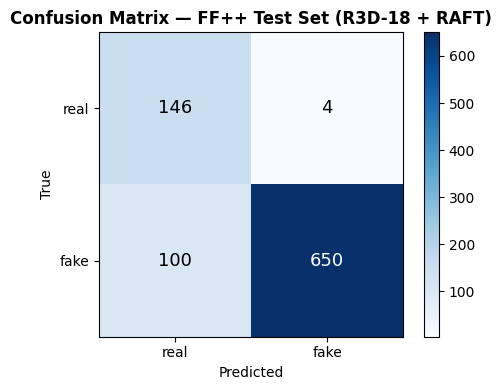

In [ ]:
print("Classification Report — FF++ Test Set (R3D-18 + RAFT):\n")
print(classification_report(raft_ffpp_m["y_true"], raft_ffpp_m["y_pred"],
                             target_names=["real", "fake"], zero_division=0))

cm = confusion_matrix(raft_ffpp_m["y_true"], raft_ffpp_m["y_pred"])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1]); ax.set_xticklabels(["real", "fake"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["real", "fake"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=13)
ax.set_title("Confusion Matrix — FF++ Test Set (R3D-18 + RAFT)", fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / "26_raft_ffpp_cm.png"), dpi=150, bbox_inches="tight")
plt.show()

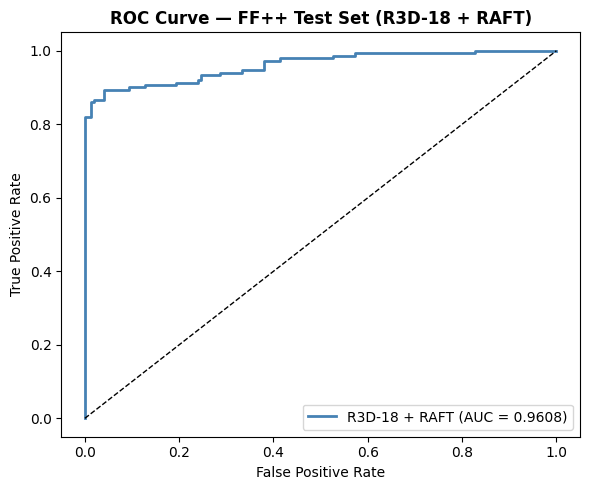

In [ ]:
fpr, tpr, _ = roc_curve(raft_ffpp_m["y_true"], raft_ffpp_m["y_prob"])
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2,
        label=f"R3D-18 + RAFT (AUC = {raft_ffpp_m['auc']:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("ROC Curve — FF++ Test Set (R3D-18 + RAFT)", fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / "26b_raft_ffpp_roc.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
print("Evaluating R3D-18 + RAFT on Celeb-DF v2 (zero-shot)...")
raft_celebdf_m = evaluate(raft_r3d, celebdf_loader, criterion, device)

print(f"\nCeleb-DF v2 Results:")
print(f"  Loss      : {raft_celebdf_m['loss']:.4f}")
print(f"  Accuracy  : {raft_celebdf_m['acc']:.4f}")
print(f"  Precision : {raft_celebdf_m['precision']:.4f}")
print(f"  Recall    : {raft_celebdf_m['recall']:.4f}")
print(f"  F1-Score  : {raft_celebdf_m['f1']:.4f}")
print(f"  AUC       : {raft_celebdf_m['auc']:.4f}")

save_results(raft_celebdf_m, MODEL_DIR / "r3d18_raft_celebdf_results.json")
print("\nCeleb-DF v2 results saved to Drive.")

Evaluating R3D-18 + RAFT on Celeb-DF v2 (zero-shot)...

Celeb-DF v2 Results:
  Loss      : 0.9896
  Accuracy  : 0.4457
  Precision : 0.9884
  Recall    : 0.3625
  F1-Score  : 0.5304
  AUC       : 0.8019

Celeb-DF v2 results saved to Drive.


Classification Report — Celeb-DF v2 (R3D-18 + RAFT):

              precision    recall  f1-score   support

        real       0.19      0.97      0.32       890
        fake       0.99      0.36      0.53      5639

    accuracy                           0.45      6529
   macro avg       0.59      0.67      0.43      6529
weighted avg       0.88      0.45      0.50      6529



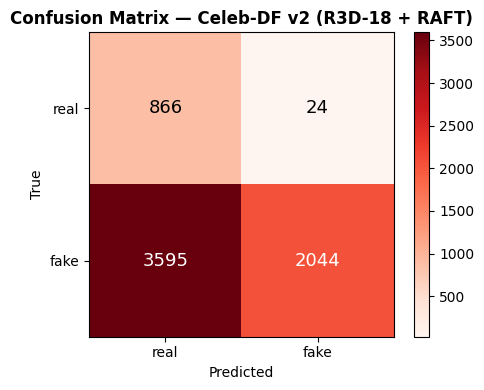

In [ ]:
print("Classification Report — Celeb-DF v2 (R3D-18 + RAFT):\n")
print(classification_report(raft_celebdf_m["y_true"], raft_celebdf_m["y_pred"],
                             target_names=["real", "fake"], zero_division=0))

cm = confusion_matrix(raft_celebdf_m["y_true"], raft_celebdf_m["y_pred"])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation="nearest", cmap="Reds")
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1]); ax.set_xticklabels(["real", "fake"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["real", "fake"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=13)
ax.set_title("Confusion Matrix — Celeb-DF v2 (R3D-18 + RAFT)", fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / "27_raft_celebdf_cm.png"), dpi=150, bbox_inches="tight")
plt.show()

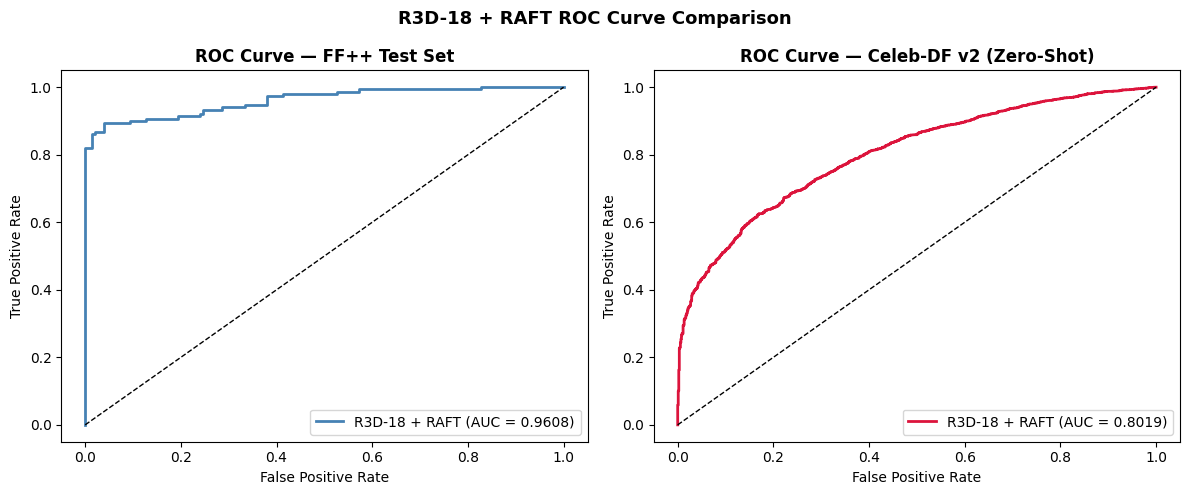

Generalization Gap (Δgen AUC) : 0.1589
  FF++ AUC     : 0.9608
  Celeb-DF AUC : 0.8019


In [ ]:
fpr_ff, tpr_ff, _ = roc_curve(raft_ffpp_m["y_true"], raft_ffpp_m["y_prob"])
fpr_cd, tpr_cd, _ = roc_curve(raft_celebdf_m["y_true"], raft_celebdf_m["y_prob"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr_ff, tpr_ff, color="steelblue", lw=2,
             label=f"R3D-18 + RAFT (AUC = {raft_ffpp_m['auc']:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_title("ROC Curve — FF++ Test Set", fontweight="bold")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")

axes[1].plot(fpr_cd, tpr_cd, color="crimson", lw=2,
             label=f"R3D-18 + RAFT (AUC = {raft_celebdf_m['auc']:.4f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_title("ROC Curve — Celeb-DF v2 (Zero-Shot)", fontweight="bold")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")

plt.suptitle("R3D-18 + RAFT ROC Curve Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / "28_raft_roc_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

gen_gap = raft_ffpp_m["auc"] - raft_celebdf_m["auc"]
print(f"Generalization Gap (Δgen AUC) : {gen_gap:.4f}")
print(f"  FF++ AUC     : {raft_ffpp_m['auc']:.4f}")
print(f"  Celeb-DF AUC : {raft_celebdf_m['auc']:.4f}")

In [ ]:
print("=" * 55)
print("R3D-18 + RAFT — FINAL RESULTS SUMMARY")
print("=" * 55)
print(f"\n{'Metric':<20} {'FF++ Test':>12} {'Celeb-DF v2':>12} {'Gap':>10}")
print("-" * 55)
for m, ff, cd in [
    ("Accuracy",  raft_ffpp_m["acc"],       raft_celebdf_m["acc"]),
    ("Precision", raft_ffpp_m["precision"], raft_celebdf_m["precision"]),
    ("Recall",    raft_ffpp_m["recall"],    raft_celebdf_m["recall"]),
    ("F1-Score",  raft_ffpp_m["f1"],        raft_celebdf_m["f1"]),
    ("AUC",       raft_ffpp_m["auc"],       raft_celebdf_m["auc"]),
]:
    print(f"  {m:<18} {ff:>12.4f} {cd:>12.4f} {ff-cd:>+10.4f}")

gen_gap = raft_ffpp_m["auc"] - raft_celebdf_m["auc"]
print(f"\n  Generalization Gap (Δgen AUC) : {gen_gap:.4f}")
print("=" * 55)

R3D-18 + RAFT — FINAL RESULTS SUMMARY

Metric                  FF++ Test  Celeb-DF v2        Gap
-------------------------------------------------------
  Accuracy                 0.8844       0.4457    +0.4387
  Precision                0.9939       0.9884    +0.0055
  Recall                   0.8667       0.3625    +0.5042
  F1-Score                 0.9259       0.5304    +0.3955
  AUC                      0.9608       0.8019    +0.1589

  Generalization Gap (Δgen AUC) : 0.1589
